In [1]:
# Part A: Data Pipeline & Preprocessing
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os 

# Path to the chest X-ray dataset
dataset_path = "C:/Users/Kaitl/chest_xray/chest_ray"
# Resize all images 
IMAGE_SIZE = (224, 224)
# Number of images processed at once during training
BATCH_SIZE = 32

In [2]:
# Paths to the training, validation, and test folders
train_dir = "C:/Users/Kaitl/chest_xray/chest_xray/train"
val_dir = "C:/Users/Kaitl/chest_xray/chest_xray/val"
test_dir = "C:/Users/Kaitl/chest_xray/chest_xray/test"

# Load images from directories and create Tensorflow datasets
train_ds = tf.keras.utils.image_dataset_from_directory(directory=train_dir, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE)
val_ds = tf.keras.utils.image_dataset_from_directory(directory=val_dir, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE)
test_ds = tf.keras.utils.image_dataset_from_directory(directory=test_dir, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


In [3]:
# Class labels for the dataset
class_names = ["NORMAL", "PNEUMONIA"]

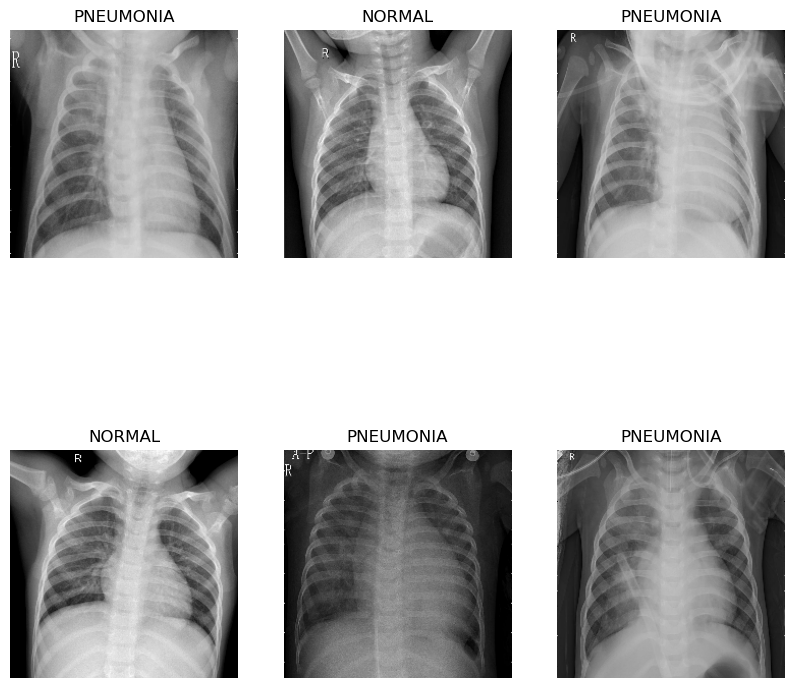

In [4]:
# Display a small sample of images from the training dataset
for features, labels in train_ds.shuffle(1000).take(1):
    plt.figure(figsize=(10, 10))

    count = 0
    for i in range(len(features)):
        if count == 6: # Limit display to 6 images
            break
        plt.subplot(2, 3, count + 1)
        # Convert image tensor to a displayable format
        plt.imshow(features[i].numpy().astype("uint8"))
        # Displat the corresponding label
        plt.title(class_names[int(labels[i].numpy())])
        plt.axis("off")
        count += 1
    plt.show()

In [13]:
# Normalize pixel values from [0, 255] to [0, 1] 
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds_normalized = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds_normalized = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds_normalized = test_ds.map(lambda x, y: (normalization_layer(x), y))

In [15]:
from tensorflow.keras import layers
# Data augmentation to increase training variability and reduce overfitting
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(factor=0.03),
    layers.RandomFlip("horizontal"),
    layers.RandomZoom(height_factor=0.1, width_factor=0.1),])

# Apply augmentation to the training dataset only
augmented_train_ds = train_ds_normalized.map(lambda x,y: (data_augmentation(x), y), num_parallel_calls=tf.data.AUTOTUNE)

In [17]:
# Part B: Model Design (The Experiment)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build a custom CNN for binary image classification
cnn_model = Sequential()
cnn_model.add(Input(shape=(224, 224, 3)))

# Convolutional blocks for feature extraction
cnn_model.add(Conv2D(filters=32, padding='same', kernel_size=(3, 3), activation='relu'))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))

cnn_model.add(Conv2D(filters=64, padding='same', kernel_size=(3, 3), activation='relu'))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))

cnn_model.add(Conv2D(filters=128, padding='same', kernel_size=(3, 3), activation='relu'))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten extracted features and pass them to dense layers
cnn_model.add(Flatten())
cnn_model.add(Dense(units=128, activation='relu'))

# Dropout helps reduce overfitting
cnn_model.add(Dropout(rate=0.5))

# Output layer for binary classification
cnn_model.add(Dense(units=1, activation='sigmoid'))

cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 100352)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      12,845,184 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,938,561 (49.36 MB)

 Trainable params: 12,938,561 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.mobilenet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D

# Load MobileNet with ImageNet weights and freeze the base model
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# Apply MobileNet preprocessing to the datasets
train_ds_preprocess = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds_preprocess = val_ds.map(lambda x, y: (preprocess_input(x), y))
test_ds_preprocess = test_ds.map(lambda x, y: (preprocess_input(x), y))

# Add a custom classification head on top of the pretrained base
transfer_model = Sequential([
    base_model, 
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(rate=0.5),
    Dense(units=1, activation='sigmoid')])

transfer_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenet_1.00_224 (Functional)      │ (None, 7, 7, 1024)          │       3,228,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1024)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         262,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,491,521 (13.32 MB)

 Trainable params: 262,657 (1.00 MB)

 Non-trainable params: 3,228,864 (12.32 MB)

In [21]:
# Part C: Training
from tensorflow.keras.callbacks import EarlyStopping

# Compile the CNN model for binary classfication
cnn_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

# Stop training early if validation loss stops improving
cnn_early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True)

# Train the CNN model
cnn_history = cnn_model.fit(
    augmented_train_ds,
    validation_data=val_ds_normalized,
    epochs=20,
    callbacks=[cnn_early_stopping],
    verbose=1
    )

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.8499 - loss: 0.3723 - val_accuracy: 0.9375 - val_loss: 0.1876
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - accuracy: 0.9132 - loss: 0.2136 - val_accuracy: 0.8125 - val_loss: 0.3906
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accuracy: 0.9260 - loss: 0.1855 - val_accuracy: 0.6875 - val_loss: 0.8555
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 169s 1s/step - accuracy: 0.9369 - loss: 0.1588 - val_accuracy: 0.7500 - val_loss: 0.9286


In [23]:
# Compile the transfer learning model
transfer_model.compile(optimizer='adam',
                       loss='binary_crossentropy',
                       metrics=['accuracy'])

# Early stopping to prevent overfitting
transfer_early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True)

# Initial training with the pretraining base model frozen
transfer_history_initial = transfer_model.fit(
    train_ds_preprocess,
    validation_data=val_ds_preprocess,
    epochs=20,
    callbacks=[transfer_early_stopping],
    verbose=1
)


Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 86s 490ms/step - accuracy: 0.9222 - loss: 0.1964 - val_accuracy: 0.8125 - val_loss: 0.3182
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 84s 500ms/step - accuracy: 0.9622 - loss: 0.0989 - val_accuracy: 0.8125 - val_loss: 0.2845
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 181s 740ms/step - accuracy: 0.9693 - loss: 0.0802 - val_accuracy: 0.9375 - val_loss: 0.1471
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 113s 561ms/step - accuracy: 0.9693 - loss: 0.0788 - val_accuracy: 0.9375 - val_loss: 0.1261
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 86s 521ms/step - accuracy: 0.9699 - loss: 0.0721 - val_accuracy: 0.9375 - val_loss: 0.1836
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 85s 518ms/step - accuracy: 0.9804 - loss: 0.0559 - val_accuracy: 0.9375 - val_loss: 0.0893
Epoch 7/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 84s 510ms/step - accuracy: 0.9747 - loss: 0.0673 - val_accuracy: 0.9375 - val_loss: 0.0956
Epoch 8/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 79s 480ms/step - accuracy: 0.9791 - loss:

In [25]:
from tensorflow.keras.optimizers import Adam
# Unfreeze the base model to allow fine-tuning
base_model.trainable = True

# Freeze earlier layers and only train deeper layers
fine_tune_at = 100
for layer in base_model.layers[: fine_tune_at]:
    layer.trainable = False

# Use a smaller learning rate for fine-tuning
base_learning_rate = 0.00001

transfer_model.compile(
    optimizer= Adam(learning_rate=base_learning_rate),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Continue training with fine-tuning enabled
transfer_history_finetune = transfer_model.fit(
    train_ds_preprocess,
    validation_data=val_ds_preprocess,
    epochs=20,
    callbacks=[transfer_early_stopping],
    verbose=1
)

Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 131s 747ms/step - accuracy: 0.9793 - loss: 0.0547 - val_accuracy: 0.9375 - val_loss: 0.1415
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 645ms/step - accuracy: 0.9814 - loss: 0.0496 - val_accuracy: 0.9375 - val_loss: 0.1420
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 147s 679ms/step - accuracy: 0.9847 - loss: 0.0450 - val_accuracy: 0.9375 - val_loss: 0.1303


In [27]:
# Part D: Evaluation & Analysis

# Evaluate the CNN model on the test dataset
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(test_ds_normalized)
print("CNN Test Loss:", cnn_test_loss)
print("CNN Test Accuracy (for reference):", cnn_test_accuracy)

# Evaluate the transfer learning model on the test dataset
transfer_test_loss, transfer_test_accuracy = transfer_model.evaluate(test_ds_preprocess)
print("Transfer Test Loss:", transfer_test_loss)
print("Transfer Test Accuracy (for reference):", transfer_test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 472ms/step - accuracy: 0.8301 - loss: 0.4395
CNN Test Loss: 0.43949875235557556
CNN Test Accuracy (for reference): 0.8301281929016113
20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 654ms/step - accuracy: 0.8205 - loss: 0.7325
Transfer Test Loss: 0.7325155735015869
Transfer Test Accuracy (for reference): 0.8205128312110901


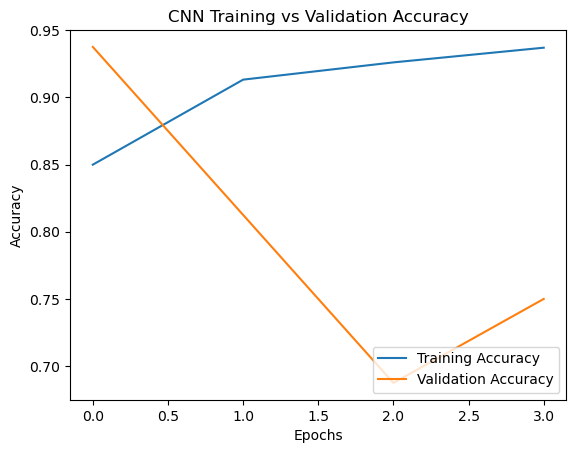

In [31]:
# Extract training and validation accuracy from training history
cnn_accuracy = cnn_history.history['accuracy']
cnn_val_accuracy = cnn_history.history['val_accuracy']
epochs = range(len(cnn_accuracy))

# Plot training vs validation accuracy over epochs
plt.plot(epochs, cnn_accuracy, label='Training Accuracy')
plt.plot(epochs, cnn_val_accuracy, label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(loc='lower right')
plt.title('CNN Training vs Validation Accuracy')
plt.show()

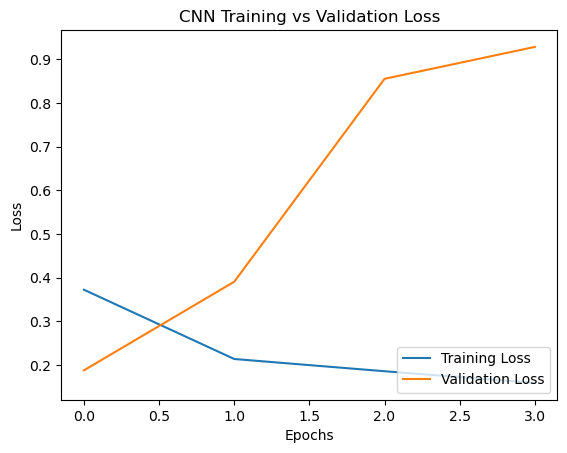

In [35]:
# Extract training and validation loss values
cnn_loss = cnn_history.history['loss']
cnn_val_loss = cnn_history.history['val_loss']
epochs = range(len(cnn_loss))

# Plot training vs validation loss over epochs
plt.plot(epochs, cnn_loss, label='Training Loss')
plt.plot(epochs, cnn_val_loss, label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(loc='lower right')
plt.title('CNN Training vs Validation Loss')
plt.show()

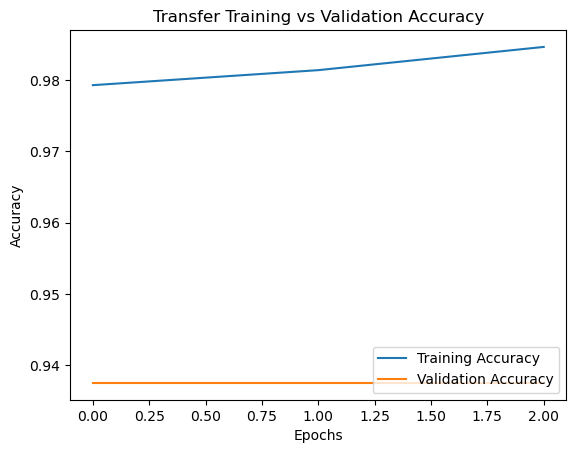

In [39]:
# Extract training and validation accuracy for the transfer learning model
transfer_accuracy = transfer_history_finetune.history['accuracy']
transfer_val_accuracy = transfer_history_finetune.history['val_accuracy']
epochs = range(len(transfer_accuracy))

# Plot training vs validation accuracy
plt.plot(epochs, transfer_accuracy, label='Training Accuracy')
plt.plot(epochs, transfer_val_accuracy, label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(loc='lower right')
plt.title('Transfer Training vs Validation Accuracy')
plt.show()

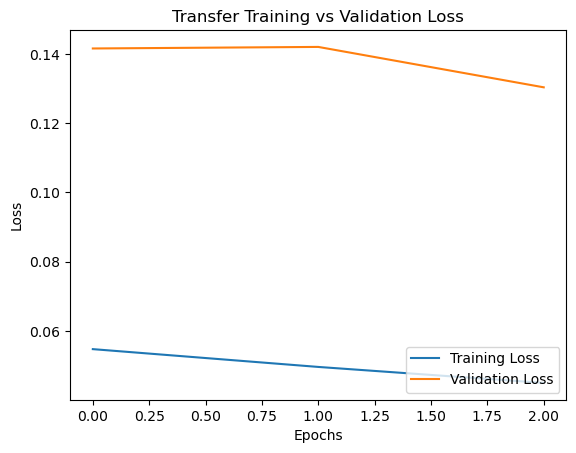

In [41]:
# Extract training and validation loss for the transfer learning model 
transfer_loss = transfer_history_finetune.history['loss']
transfer_val_loss = transfer_history_finetune.history['val_loss']
epochs = range(len(transfer_loss))

# Plot training vs validation loss
plt.plot(epochs, transfer_loss, label='Training Loss')
plt.plot(epochs, transfer_val_loss, label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(loc='lower right')
plt.title('Transfer Training vs Validation Loss')
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 389ms/step
CNN True Negative: 58
CNN False Positives: 176
CNN False Negatives: 102
CNN True Positives: 288
CNN Recall: 0.7384615384615385
CNN Precision: 0.6206896551724138
CNN F1 Score: 0.6744730679156908


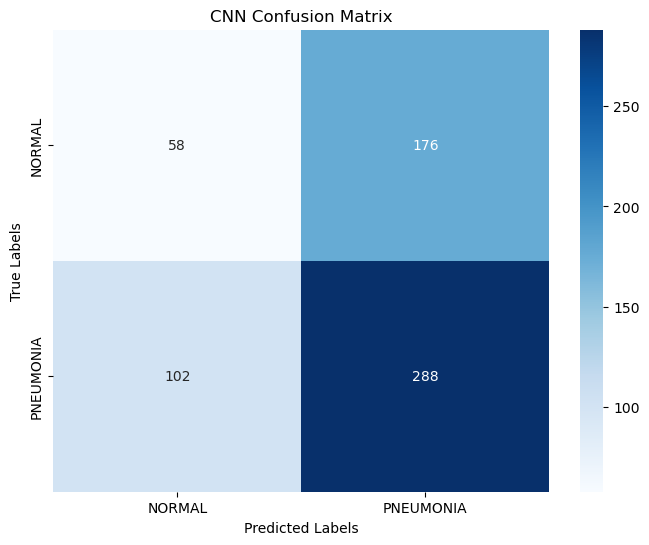

In [43]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns

# Generate predictions from the CNN model on the test dataset
cnn_predictions = cnn_model.predict(test_ds_normalized)

# Convert predicted probabilities to binary class labels
cnn_predicted_classes = (cnn_predictions >= 0.5).astype(int).flatten()

# Collect the true lables from the test dataset
cnn_true_classes = []
for images, labels in test_ds_normalized:
        cnn_true_classes.extend(labels.numpy())

cnn_true_classes = np.array(cnn_true_classes)

# Define class names for labeling the confusion matrix
cnn_class_labels = ["NORMAL", "PNEUMONIA"]

# Compute confusion matrix comparing true vs predicted labels
cnn_cm = confusion_matrix(cnn_true_classes, cnn_predicted_classes)

# Extract confusion matrix values
cnn_tn, cnn_fp, cnn_fn, cnn_tp = cnn_cm.ravel()

# Print confusion matrix components
print("CNN True Negative:", cnn_tn)
print("CNN False Positives:", cnn_fp)
print("CNN False Negatives:", cnn_fn)
print("CNN True Positives:", cnn_tp)

# Calculate evaluation metrics
print("CNN Recall:", recall_score(cnn_true_classes, cnn_predicted_classes))
print("CNN Precision:", precision_score(cnn_true_classes, cnn_predicted_classes))
print("CNN F1 Score:", f1_score(cnn_true_classes, cnn_predicted_classes))

# Visualize the confusion matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cnn_cm, annot=True, fmt='d', cmap='Blues', xticklabels=cnn_class_labels, yticklabels=cnn_class_labels)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("CNN Confusion Matrix")
plt.show()

20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 761ms/step
Transfer True Negatives: 55
Transer False Positives: 179
Transfer False Negatives: 71
Transfer False Positives: 319
Transfer Recall: 0.8179487179487179
Transfer Precision: 0.6405622489959839
Transfer F1 Score: 0.7184684684684685


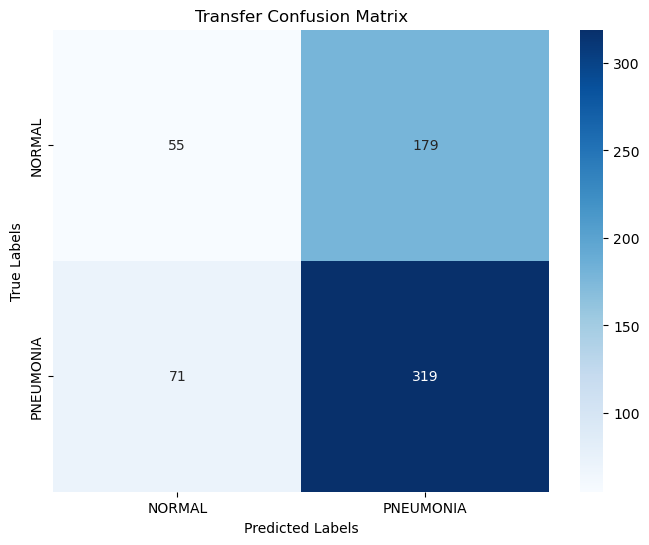

In [45]:
# Generate predictions from the transfer learning model
transfer_predictions = transfer_model.predict(test_ds_preprocess)

# Convert predicted probabilities into binary class labels
transfer_predicted_classes = (transfer_predictions >= 0.5).astype(int).flatten()

# Collect the true labels from the test dataset
transfer_true_classes = []
for images, labels in test_ds_preprocess:
        transfer_true_classes.extend(labels.numpy())

transfer_true_classes = np.array(transfer_true_classes)

# Define class names for the confusion matrix
transfer_class_labels = ["NORMAL", "PNEUMONIA"]

# Compute confusion matrix comparing predicted vs true labels
transfer_cm = confusion_matrix(transfer_true_classes, transfer_predicted_classes)

# Extract confusion matrix values
transfer_tn, transfer_fp, transfer_fn, transfer_tp = transfer_cm.ravel()

# Print confusion matrix components
print("Transfer True Negatives:", transfer_tn)
print("Transer False Positives:", transfer_fp)
print("Transfer False Negatives:", transfer_fn)
print("Transfer False Positives:", transfer_tp)

# Calculate evaluation metrics
print("Transfer Recall:", recall_score(transfer_true_classes, transfer_predicted_classes))
print("Transfer Precision:", precision_score(transfer_true_classes, transfer_predicted_classes))
print("Transfer F1 Score:", f1_score(transfer_true_classes, transfer_predicted_classes))

# Visualize confusion matrix for the transfer learning model
plt.figure(figsize=(8, 6))
sns.heatmap(transfer_cm, annot=True, fmt='d', cmap='Blues', xticklabels=transfer_class_labels, yticklabels=transfer_class_labels)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Transfer Confusion Matrix")
plt.show()

Model 1 and Model 2 were created to classify chest X-ray images as either normal or pneumonia: a custom convolutional neural network (CNN) and a transfer learning model based on MobileNet. Both models learned meaningful patterns from the dataset, but the transfer learning model performed better. The CNN achieved a slightly higher accuracy, but its confusion matrix showed a higher number of false negatives and false positives compared to the transfer model. However, the transfer learning model correctly identified more pneumonia cases and produced a higher recall and F1-score. This hints that the pretrained MobileNet features helped the model generalize better on this small medical imaging dataset.

Recall is important in a medical diagnosis task such as pnemonia detection as it measures how many actual pneumoia cases are correctly identified by the model. A false negative occurs when a sick patient is predicted to be healthy, which can be dangerous because the patient may not receive necessary treatment. Therefore, it is more important to overestimate recall even if it results in some false positives. In practice, false positives can be followed up with additional tests, but missing a pneumonia case could delay medical care. Overall, the transfer learning model demonstrated better performance and reliability for detecting pneumonia cases.